# This Notbook version
Data Prep: 50%(No Label) | 50% (Label) -> sampling each card distribution with Weight sampling

# Preparation

In [ ]:
# 2. Install synchronized versions for Python 3.12 (Feb 2026 stable)
!pip install -q torch torchvision torchaudio
!pip install -q datasets==3.6.0 sympy transformers evaluate sentencepiece accelerate scikit-multilearn pythainlp emoji pandarallel

In [1]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict, load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, hamming_loss
import numpy as np
import warnings
import evaluate
import os
from pandarallel import pandarallel
import seaborn as sns
import matplotlib as mpl
warnings.filterwarnings("ignore")

# Initialize with the number of available CPUs
pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
# DO NOT include the brackets, just the string inside the quotes
os.environ['KAGGLE_USERNAME'] = "mysterioucz"
os.environ['KAGGLE_KEY'] = "61589d30f7cb3a67f84e1a3b69b7add9"

# Try the list again
!kaggle competitions list

ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd       2747           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured   1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured   1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured   1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detec

# EDA

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df_test = pd.read_csv('test.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306419 entries, 0 to 306418
Data columns (total 14 columns):
 #   Column                                 Non-Null Count   Dtype 
---  ------                                 --------------   ----- 
 0   id                                     306419 non-null  int64 
 1   comment                                304284 non-null  object
 2   สำนักงานตำรวจแห่งชาติ                  306419 non-null  int64 
 3   การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย      306419 non-null  int64 
 4   สภาเด็กและเยาวชนกรุงเทพมหานคร          306419 non-null  int64 
 5   กรมควบคุมมลพิษ                         306419 non-null  int64 
 6   กรมสรรพสามิต                           306419 non-null  int64 
 7   การไฟฟ้านครหลวง                        306419 non-null  int64 
 8   กรมทางหลวง                             306419 non-null  int64 
 9   สำนักงานประกันสุขภาพแห่งชาติ           306419 non-null  int64 
 10  การประปานครหลวง                        306419 non-null  int64 
 11  

In [6]:
df.head()

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว,0,0,0,0,0,0,0,0,0,0,0,0
1,1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
2,2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...,0,0,0,0,0,0,0,0,0,0,0,0
3,3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...,0,0,0,0,0,0,0,0,0,0,0,0
4,4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
df_test.head()

,id,comment
0,0,รถติดจังเลยครับ อยากได้เกาะกลาง ที่ขยับเพิ่มเล...
1,1,ในซอยมีการเตรียมทำท่อระบายน้ำ โดยผู้รับเหมา มา...
2,2,มีต้นไม้กีดขวางทางสัญจรไปมาทำให้เกิดอันตราย
3,3,ร้านนวดบริเวณนี้วางของเกะกะบนทางเท้ามากมาย
4,4,ศูนย์เรื่องราวร้องทุกข์ ได้รับการประสานผ่านระบ...


In [8]:
classes = df.columns[2:].values
class2id = {class_: id for id, class_ in enumerate(classes)}
id2class = {id: class_ for class_, id in class2id.items()}
print(classes)


['สำนักงานตำรวจแห่งชาติ' 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย'
 'สภาเด็กและเยาวชนกรุงเทพมหานคร' 'กรมควบคุมมลพิษ' 'กรมสรรพสามิต'
 'การไฟฟ้านครหลวง' 'กรมทางหลวง' 'สำนักงานประกันสุขภาพแห่งชาติ'
 'การประปานครหลวง' 'คณะกรรมการการพัฒนาเศรษฐกิจ'
 'กระทรวงการท่องเที่ยวและกีฬา' 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200']


In [9]:
# Exclude 'comment' column from the label classes
label_counts = df[classes].sum(axis=0).sort_values(ascending=False)
labels_perc = (label_counts/df.shape[0])*100
print(labels_perc)
print(f"total perc {labels_perc.sum(axis=0)}")

สำนักงานตำรวจแห่งชาติ                    11.486886
การไฟฟ้านครหลวง                           6.546265
กรมทางหลวง                                2.512246
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200     1.498928
การประปานครหลวง                           0.992106
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย         0.855038
กรมควบคุมมลพิษ                            0.644869
สำนักงานประกันสุขภาพแห่งชาติ              0.025455
กรมสรรพสามิต                              0.015991
กระทรวงการท่องเที่ยวและกีฬา               0.013707
สภาเด็กและเยาวชนกรุงเทพมหานคร             0.010770
คณะกรรมการการพัฒนาเศรษฐกิจ                0.009791
dtype: float64
total perc 24.61205081930298


## Note
This mean that there are at least 76% of data that dont have any label?

In [10]:
df.shape[0]

306419

In [11]:
df["label_count"] = df[classes].sum(axis=1)
df.loc[df["label_count"] == 0, ["comment"]]

,comment
0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว
1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...
2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...
3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...
4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...
...,...
306414,ขับรถบนทางเท้า
306415,ฝาท่อน้ำเหล็ก ข้างร้านเดอะโลคอล ซ.สุชุมวิท 23 ...
306416,กรุณาตรวจสอบการดำเนินการก่อสร้างฟุตบาทถนนพุทธบ...
306417,ถนนศรีอยุธยาชำรุด บริเวณหน้าทางเข้าตึกวรรณสรณ์...


# Preprocess


## Clean Data

In [12]:
"""
Copied from thai2transformers (https://github.com/vistec-AI/thai2transformers/blob/master/thai2transformers/preprocess.py)
"""
from typing import Collection, Callable
import re
import html
import emoji
from pythainlp.tokenize import word_tokenize

_TK_UNK, _TK_REP, _TK_WREP, _TK_URL, _TK_END = "<unk> <rep> <wrep> <url> </s>".split()

SPACE_SPECIAL_TOKEN = "<_>"

# Pre-compile regex patterns
_RE_HTML_SPACES = re.compile(r"  +")
_RE_URL = re.compile(r"(http|ftp|https)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?")
_RE_EMPTY_BRACKETS = re.compile(r"\(\)|\{\}|\[\]")
_RE_BRACKETS_PUNCTUATION = re.compile(r"\([^a-zA-Z0-9ก-๙]+\)|\{[^a-zA-Z0-9ก-๙]+\}|\[[^a-zA-Z0-9ก-๙]+\]")
_RE_ARTIFACTS_AFTER_OPEN = re.compile(r"(?<=\()[^a-zA-Z0-9ก-๙]+(?=[a-zA-Z0-9ก-๙])|(?<=\{)[^a-zA-Z0-9ก-๙]+(?=[a-zA-Z0-9ก-๙])|(?<=\[)[^a-zA-Z0-9ก-๙]+(?=[a-zA-Z0-9ก-๙])")
_RE_ARTIFACTS_BEFORE_CLOSE = re.compile(r"(?<=[a-zA-Z0-9ก-๙])[^a-zA-Z0-9ก-๙]+(?=\))|(?<=[a-zA-Z0-9ก-๙])[^a-zA-Z0-9ก-๙]+(?=\})|(?<=[a-zA-Z0-9ก-๙])[^a-zA-Z0-9ก-๙]+(?=\])")
_RE_NEWLINES = re.compile(r"[\n]")
_RE_USELESS_SPACES = re.compile(r" {2,}")
_RE_SPACES = re.compile(r" ")
_RE_REP = re.compile(r"(\S)(\1{3,})")

# str->str rules
def fix_html(text: str) -> str:
    """
        List of replacements from html strings in `test`. (code from `fastai`)
        :param str text: text to replace html string
        :return: text where html strings are replaced
        :rtype: str
        :Example:
            >>> fix_html("Anbsp;amp;nbsp;B @.@ ")
            A & B.
    """
    text = (
        text.replace("#39;", "'")
        .replace("amp;", "&")
        .replace("#146;", "'")
        .replace("nbsp;", " ")
        .replace("#36;", "$")
        .replace("\\n", "\n")
        .replace("quot;", "'")
        .replace("<br />", "\n")
        .replace('\\"', '"')
        .replace(" @.@ ", ".")
        .replace(" @-@ ", "-")
        .replace(" @,@ ", ",")
        .replace("\\", " \\ ")
    )
    return _RE_HTML_SPACES.sub(" ", html.unescape(text))

def replace_url(text: str) -> str:
    """
        Replace url in `text` with TK_URL (https://stackoverflow.com/a/6041965)
        :param str text: text to replace url
        :return: text where urls  are replaced
        :rtype: str
        :Example:
            >>> replace_url("go to https://github.com")
            go to <url>
    """
    return _RE_URL.sub(_TK_URL, text)

def rm_brackets(text: str) -> str:
    """
        Remove all empty brackets and artifacts within brackets from `text`.
        :param str text: text to remove useless brackets
        :return: text where all useless brackets are removed
        :rtype: str
        :Example:
            >>> rm_brackets("hey() whats[;] up{*&} man(hey)")
            hey whats up man(hey)
    """
    # remove empty brackets
    new_line = _RE_EMPTY_BRACKETS.sub("", text)
    # brakets with only punctuations
    new_line = _RE_BRACKETS_PUNCTUATION.sub("", new_line)
    # artifiacts after (
    new_line = _RE_ARTIFACTS_AFTER_OPEN.sub("", new_line)
    # artifacts before )
    new_line = _RE_ARTIFACTS_BEFORE_CLOSE.sub("", new_line)
    return new_line

def replace_newlines(text: str) -> str:
    """
        Replace newlines in `text` with spaces.
        :param str text: text to replace all newlines with spaces
        :return: text where all newlines are replaced with spaces
        :rtype: str
        :Example:
            >>> rm_useless_spaces("hey whats\n\nup")
            hey whats  up
    """
    return _RE_NEWLINES.sub(" ", text.strip())

def rm_useless_spaces(text: str) -> str:
    """
        Remove multiple spaces in `text`. (code from `fastai`)
        :param str text: text to replace useless spaces
        :return: text where all spaces are reduced to one
        :rtype: str
        :Example:
            >>> rm_useless_spaces("oh         no")
            oh no
    """
    return _RE_USELESS_SPACES.sub(" ", text)

def replace_spaces(text: str, space_token: str = SPACE_SPECIAL_TOKEN) -> str:
    """
        Replace spaces with _
        :param str text: text to replace spaces
        :return: text where all spaces replaced with _
        :rtype: str
        :Example:
            >>> replace_spaces("oh no")
            oh_no
    """
    return _RE_SPACES.sub(space_token, text)

def replace_rep_after(text: str) -> str:
    """
    Replace repetitions at the character level in `text`
    :param str text: input text to replace character repetition
    :return: text with repetitive tokens removed.
    :rtype: str
    :Example:
        >>> text = "กาาาาาาา"
        >>> replace_rep_after(text)
        'กา'
    """

    def _replace_rep(m):
        c, cc = m.groups()
        return f"{c}"

    return _RE_REP.sub(_replace_rep, text)

# List[str] -> List[str] rules
def ungroup_emoji(toks: Collection[str]) -> Collection[str]:
    """
    Ungroup Zero Width Joiner (ZVJ) Emojis
    See https://emojipedia.org/emoji-zwj-sequence/
    :param Collection[str] toks: list of tokens
    :return: list of tokens where emojis are ungrouped
    :rtype: Collection[str]
    :Example:
        >>> toks = []
        >>> ungroup_emoji(toks)
        []
    """
    res = []
    for tok in toks:
        if emoji.emoji_count(tok) == len(tok):
            res.extend(list(tok))
        else:
            res.append(tok)
    return res

def replace_wrep_post(toks: Collection[str]) -> Collection[str]:
    """
    Replace reptitive words post tokenization;
    fastai `replace_wrep` does not work well with Thai.
    :param Collection[str] toks: list of tokens
    :return: list of tokens where repetitive words are removed.
    :rtype: Collection[str]
    :Example:
        >>> toks = ["กา", "น้ำ", "น้ำ", "น้ำ", "น้ำ"]
        >>> replace_wrep_post(toks)
        ['กา', 'น้ำ']
    """
    previous_word = None
    rep_count = 0
    res = []
    for current_word in toks + [_TK_END]:
        if current_word == previous_word:
            rep_count += 1
        elif (current_word != previous_word) & (rep_count > 0):
            res += [previous_word]
            rep_count = 0
        else:
            res.append(previous_word)
        previous_word = current_word
    return res[1:]

def remove_space(toks: Collection[str]) -> Collection[str]:
    """
    Do not include space for bag-of-word models.
    :param Collection[str] toks: list of tokens
    :return: Collection of tokens where space tokens (" ") are filtered out
    :rtype: Collection[str]
    :Example:
        >>> toks = ['ฉัน','เดิน',' ','กลับ','บ้าน']
        >>> remove_space(toks)
        ['ฉัน','เดิน','กลับ','บ้าน']
    """
    res = []
    for t in toks:
        t = t.strip()
        if t:
            res.append(t)
    return res

# combine them together
def process_transformers(
    text: str,
    pre_rules: Collection[Callable] = [
        fix_html,
        rm_brackets,
        replace_newlines,
        rm_useless_spaces,
        replace_spaces,
        replace_rep_after,
    ],
    tok_func: Callable = word_tokenize,
    post_rules: Collection[Callable] = [ungroup_emoji, replace_wrep_post],
) -> str:
    text = text.lower()
    for rule in pre_rules:
        text = rule(text)
    return text


In [13]:
def text_clean(text):
    # Ensure input is string
    if not isinstance(text, str):
        return ""

    text = process_transformers(text)

    return text

In [14]:
def clean_data(df):
  df['comment'] = df['comment'].fillna("")
  df['comment'] = df['comment'].parallel_apply(text_clean)
  return df


In [15]:
df = df.drop(columns=['id'],axis=1) # remove id
df = clean_data(df)
df_test = clean_data(df_test)


In [16]:
df["label_count"] = df[classes].sum(axis=1)
df.loc[df["label_count"] == 0, ["comment"]]

,comment
0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว
1,แจ้งว่าการจุดพลุต้องขออนุญาต<_>ทำไมจุดกันมากมา...
2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง<_>ส...
3,ไม่แน่ใจ<_>กทม<_>อนุญาตให้ร้านชอคโกแลตวิลจุพลุ...
4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้<_>เปิดเสียงเพลง...
...,...
306414,ขับรถบนทางเท้า
306415,ฝาท่อน้ำเหล็ก<_>ข้างร้านเดอะโลคอล<_>ซ.สุชุมวิท...
306416,กรุณาตรวจสอบการดำเนินการก่อสร้างฟุตบาทถนนพุทธบ...
306417,ถนนศรีอยุธยาชำรุด<_>บริเวณหน้าทางเข้าตึกวรรณสร...


## Train Test Split

In [17]:
X = df[['comment']].values
y = df[classes].values

In [18]:
y

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(306419, 12))

In [19]:
from skmultilearn.model_selection import iterative_train_test_split

In [20]:
X_train_arr,y_train_arr ,X_eval_arr, y_eval_arr = iterative_train_test_split(
    X, y, test_size=0.2
)

In [21]:
# 3. Reconstruct DataFrames
df_train = pd.DataFrame(X_train_arr, columns=['comment'])
df_train[classes] = y_train_arr

df_eval = pd.DataFrame(X_eval_arr, columns=['comment'])
df_eval[classes] = y_eval_arr


## Analyze Class Distribution

Calculate and visualize the distribution of labels in the training set to identify minority and majority classes.


**Reasoning**:
Calculate the class distribution by summing the label columns in the training dataframe and visualize it using a bar chart.



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [23]:
# !wget -q "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = "Sarabun-Regular.ttf"

In [24]:
mpl.font_manager.fontManager.addfont(font_path)
mpl.rc('font', family='Sarabun')

In [25]:
def class_distribution(df_train):
    # Calculate the sum of each class in the training set
    class_counts = df_train[classes].sum().sort_values(ascending=False)
    class_counts["no_label"] = sum(df_train[classes].sum(axis=1) == 0)
    # Print the numerical counts
    print("Class Counts in Training Set:")
    print(class_counts)

    # Create a bar chart
    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
    plt.title('Class Distribution in Training Set')
    plt.xlabel('Count')
    plt.ylabel('Class')
    plt.show()

Class Counts in Training Set:
สำนักงานตำรวจแห่งชาติ                     28158
การไฟฟ้านครหลวง                           16047
กรมทางหลวง                                 6158
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200      3674
การประปานครหลวง                            2432
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย          2096
กรมควบคุมมลพิษ                             1581
สำนักงานประกันสุขภาพแห่งชาติ                 62
กรมสรรพสามิต                                 39
กระทรวงการท่องเที่ยวและกีฬา                  34
สภาเด็กและเยาวชนกรุงเทพมหานคร                26
คณะกรรมการการพัฒนาเศรษฐกิจ                   24
no_label                                 186598
dtype: int64


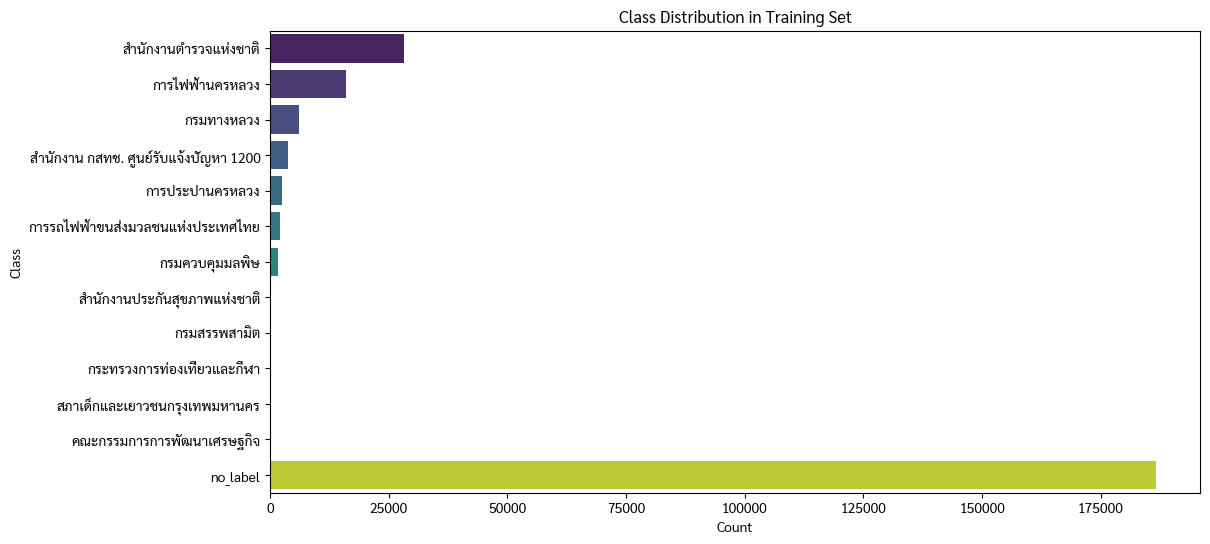

In [26]:
class_distribution(df_train)

**Reasoning**:
The previous step showed a significant class imbalance. Now I need to implement the resampling strategy as requested. This involves creating a function that separates minority and majority classes, oversamples the minority ones, undersamples the majority ones (keeping high multi-label density samples), and then combines them back.



In [55]:
def balance_dataset_optimized(df, labels, target_total_samples=50000, alpha=0.5, background_ratio=0.15):
    """
    Balances multi-label dataset while maintaining a fixed ratio of 'background' (no-label) examples.
    """
    print(f"Original shape: {df.shape}")
    
    # 1. Identify Labeled vs Unlabeled Data
    # Calculate density to split them apart
    # Make a copy to avoid SettingWithCopy warnings
    df = df.copy()
    df['label_count'] = df[labels].sum(axis=1)
    
    df_labeled = df[df['label_count'] > 0]
    df_background = df[df['label_count'] == 0]
    
    print(f"Labeled samples: {len(df_labeled)}")
    print(f"Background (No Label) samples: {len(df_background)}")

    # 2. Calculate sizes for the final mix
    n_background = int(target_total_samples * background_ratio)
    n_labeled = target_total_samples - n_background
    
    print(f"Target Mix: {n_labeled} Labeled | {n_background} Background")

    # --- PROCESS LABELED DATA (Weighted Sampling) ---
    # 3. Calculate label weights (Inverse Frequency) on the LABELED portion only
    label_counts = df_labeled[labels].sum()
    total_labels = label_counts.sum()
    
    # Rare labels get higher weight
    label_weights = total_labels / (label_counts + 1)
    
    # 4. Assign "Importance Score" to labeled rows
    # We use the MAX weight of the labels present in the row
    # Vectorized: weighted_matrix will have non-zero values where labels exist
    weighted_matrix = df_labeled[labels].multiply(label_weights, axis=1)
    row_scores = weighted_matrix.max(axis=1)
    
    # Apply smoothing alpha
    row_scores = row_scores ** alpha 

    # Sample the labeled portion
    df_balanced_labeled = df_labeled.sample(
        n=n_labeled,
        weights=row_scores,
        replace=True,
        random_state=42
    )

    # --- PROCESS BACKGROUND DATA (Random Sampling) ---
    # 5. Sample the background portion
    if len(df_background) > 0:
        # If we have enough unique background samples, we try not to replace
        replace_bg = len(df_background) < n_background
        df_balanced_background = df_background.sample(
            n=n_background,
            replace=replace_bg,
            random_state=42
        )
    else:
        df_balanced_background = pd.DataFrame(columns=df.columns)

    # 6. Combine and Shuffle
    # Drop the temporary column before concatenating or after
    df_balanced_labeled = df_balanced_labeled.drop(columns=['label_count'])
    df_balanced_background = df_balanced_background.drop(columns=['label_count'])
    
    df_final = pd.concat([df_balanced_labeled, df_balanced_background])
    df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"Final dataset size: {len(df_final)}")
    # print("Final Label Distribution:\n", df_final[labels].sum())
    
    return df_final

# Try using alpha=0.7 for strong balancing
# Reserve 15% of the dataset for "background" examples so the model learns to predict "nothing"
df_train_balanced = balance_dataset_optimized(
    df_train, 
    classes, 
    target_total_samples=70000, 
    alpha=0.7, 
    background_ratio=0.6
)

Original shape: (245135, 13)
Labeled samples: 58537
Background (No Label) samples: 186598
Target Mix: 28000 Labeled | 42000 Background
Final dataset size: 70000


Class Counts in Training Set:
สำนักงานตำรวจแห่งชาติ                     6302
การไฟฟ้านครหลวง                           5527
กรมทางหลวง                                3795
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200     3136
การประปานครหลวง                           2688
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย         2625
กรมควบคุมมลพิษ                            2487
สำนักงานประกันสุขภาพแห่งชาติ               890
กรมสรรพสามิต                               764
กระทรวงการท่องเที่ยวและกีฬา                745
สภาเด็กและเยาวชนกรุงเทพมหานคร              684
คณะกรรมการการพัฒนาเศรษฐกิจ                 640
no_label                                 42000
dtype: int64


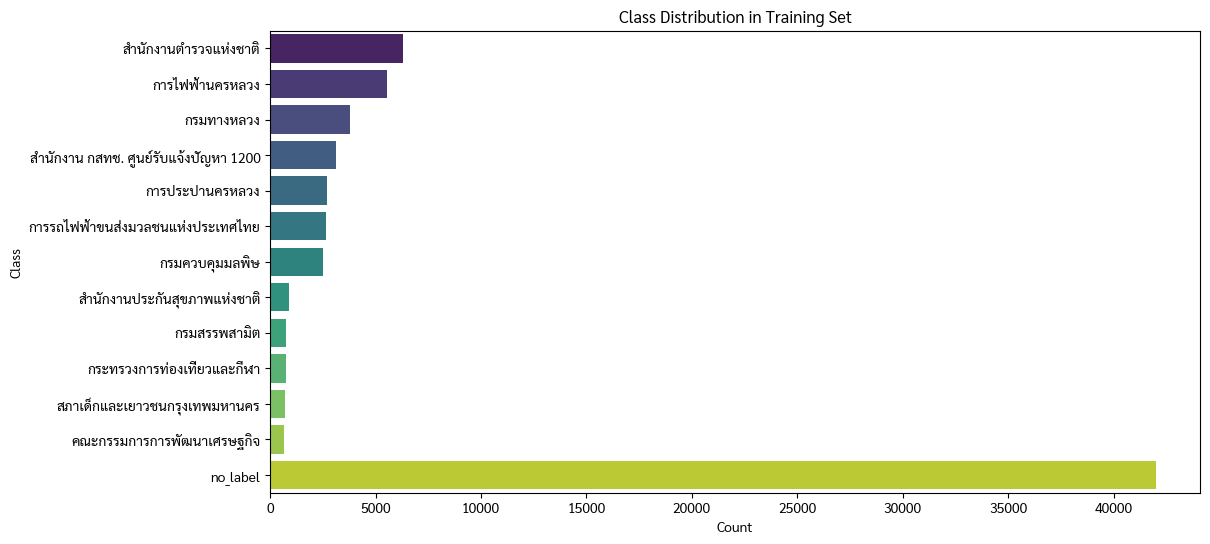

In [56]:
class_distribution(df_train_balanced)

In [57]:

# 4. Convert to Hugging Face Datasets
hf_train = Dataset.from_pandas(df_train_balanced)
hf_eval = Dataset.from_pandas(df_eval)
hf_test = Dataset.from_pandas(df_test)

# 5. Map to DatasetDict
raw_datasets = DatasetDict({
    'train': hf_train,
    'eval': hf_eval,
    'test': hf_test  # Ensure df_test was defined earlier
})

In [58]:
from transformers import AutoTokenizer

model_path = 'clicknext/phayathaibert'

tokenizer = AutoTokenizer.from_pretrained(model_path)

In [59]:
def optimized_preprocess(batches):
    # 1. Tokenize the entire batch of texts at once
    tokenized_inputs = tokenizer(
        batches['comment'],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # 2. Extract labels only if they exist (Train/Eval)
    # We check if the first class column is present in the batch
    if classes[0] in batches:
        batch_labels = []
        for i in range(len(batches['comment'])):
            labels = [float(batches[col][i]) for col in classes]
            batch_labels.append(labels)
        tokenized_inputs['labels'] = batch_labels

    return tokenized_inputs

# Process Train, Eval, and Test
tokenized_train = raw_datasets['train'].map(
    optimized_preprocess,
    batched=True,
    remove_columns=raw_datasets['train'].column_names
)

tokenized_eval = raw_datasets['eval'].map(
    optimized_preprocess,
    batched=True,
    remove_columns=raw_datasets['eval'].column_names
)

# Test set usually doesn't have labels, so the function handles that
tokenized_test = raw_datasets['test'].map(
    optimized_preprocess,
    batched=True,
    remove_columns=raw_datasets['test'].column_names
)


Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

Map:   0%|          | 0/61284 [00:00<?, ? examples/s]

Map:   0%|          | 0/37406 [00:00<?, ? examples/s]

In [60]:
from datasets import DatasetDict

tokenized_datasets = DatasetDict({
    'train': tokenized_train,
    'eval': tokenized_eval,
    'test': tokenized_test
})

In [61]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [62]:
# Calculate Class Weights based on the original training distribution
# This helps the model pay more attention to underrepresented classes
import torch
import numpy as np

# We use the original df_train to calculate true distribution weights
# (Even if we use the balanced dataset for training, checking weights against real distribution is useful,
# but typically we use the weights of the dataset we are actually training on if we want to force balance further,
# or use original weights if we want to counteract the natural imbalance).
# Here we calculate based on the training data we are fed (df_train_balanced or df_train).

# Let's use the df_train (original) to get the "real" difficulty of each class
labels_tensor = torch.tensor(df_train[classes].values, dtype=torch.float)
pos_counts = torch.sum(labels_tensor, dim=0)
neg_counts = len(df_train) - pos_counts

# Formula: pos_weight = neg_counts / pos_counts
# This makes the loss for a positive example of a rare class much larger.
pos_weights = neg_counts / (pos_counts + 1e-5) # 1e-5 to avoid division by zero

print("Class Weights (Pos Weight):", pos_weights)

Class Weights (Pos Weight): tensor([7.7057e+00, 1.1595e+02, 9.4273e+03, 1.5405e+02, 6.2845e+03, 1.4276e+01,
        3.8808e+01, 3.9528e+03, 9.9796e+01, 1.0213e+04, 7.2089e+03, 6.5722e+01])


# Metric

In [63]:
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

best_thresholds = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))

    thresholds = getattr(compute_metrics, "thresholds", [0.5] * labels.shape[1])

    y_pred = np.zeros(probs.shape)
    for i in range(labels.shape[1]):
        y_pred[:, i] = (probs[:, i] > thresholds[i]).astype(int)

    # Hamming Loss: misclassified example-label pairs (lower is better)
    h_loss = hamming_loss(labels, y_pred)

    # Subset Accuracy: strict match for all labels (higher is better)
    subset_acc = accuracy_score(labels, y_pred)

    return {
        # Core metrics for imbalanced multi-label data
        "hamming_loss": h_loss,
        "micro_f1": f1_score(labels, y_pred, average='micro', zero_division=0),

        # Macro metrics for balanced class awareness
        "macro_f1": f1_score(labels, y_pred, average='macro', zero_division=0),
        "precision_macro": precision_score(labels, y_pred, average='macro', zero_division=0),
        "recall_macro": recall_score(labels, y_pred, average='macro', zero_division=0),

        # Performance/Categorization metrics
        "subset_accuracy": subset_acc,
        "example_based_accuracy": np.mean(np.all(labels == y_pred, axis=1)) # Strict example accuracy
    }

compute_metrics.thresholds = [0.5] * len(classes)


# Model

In [64]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=len(classes),
    id2label=id2class,
    label2id=class2id,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: clicknext/phayathaibert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##

# Training

In [65]:
os.environ["WANDB_API_KEY"]="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"

In [66]:
from torch import nn
from transformers import Trainer

class MultilabelTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Ensure weights are on the same device as the model
        if class_weights is not None:
            self.class_weights = class_weights.to(self.model.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Binary Cross Entropy with Logits Loss + Class Weights
        if self.class_weights is not None:
             # Ensure weights are on the same device as the model/logits
            if self.class_weights.device != logits.device:
                self.class_weights = self.class_weights.to(logits.device)
            loss_fct = nn.BCEWithLogitsLoss(pos_weight=self.class_weights)
        else:
            loss_fct = nn.BCEWithLogitsLoss()

        loss = loss_fct(logits.view(-1, self.model.config.num_labels),
                        labels.float().view(-1, self.model.config.num_labels))

        return (loss, outputs) if return_outputs else loss

In [67]:
import wandb
# This forcefully stops the wandb background process
wandb.init(project="multi-label-classify", name="weighted-bert-v1")

eval/example_based_accuracy,▅▁▆██▇
eval/hamming_loss,▃█▃▁▁▂
eval/loss,▆█▃▁▁▂
eval/macro_f1,▁▆▆▆▆█
eval/micro_f1,▂▁▆█▆▇
eval/precision_macro,▁▆▇▆▇█
eval/recall_macro,▃█▁▃▂▇
eval/runtime,██▁▅▇▄
eval/samples_per_second,▁▁█▄▂▅
eval/steps_per_second,▁▁█▄▂▅
+17,...


In [68]:
# Monitor via wandb
report_to = "wandb"

training_args = TrainingArguments(
    output_dir="my_multi_label_classify_model_weighted",
    learning_rate=3e-5,              # Slightly higher initial LR for BERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,              # Increase epochs (early stopping will catch it)
    weight_decay=0.01,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=2000,                  # Evaluate more frequently
    save_steps=2000,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to=report_to,
    warmup_ratio=0.1,
    bf16=True,                       # Keep fp16/bf16
    metric_for_best_model="macro_f1", # Essential for imbalanced data
    lr_scheduler_type="cosine",      # Cosine schedule
    seed=42,
    data_seed=42,
    full_determinism=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [69]:
%%time
# Initialize the Custom Trainer
trainer = MultilabelTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['eval'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=pos_weights  # Pass the calculated weights here
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 6, 'bos_token_id': 5}.


Step,Training Loss,Validation Loss,Hamming Loss,Micro F1,Macro F1,Precision Macro,Recall Macro,Subset Accuracy,Example Based Accuracy,Runtime,Samples Per Second,Steps Per Second
2000,2.968358,1.017148,0.067447,0.336858,0.199955,0.135752,0.727534,0.491792,0.491792,66.749900,918.113000,57.393000
4000,0.825553,1.140849,0.069903,0.339284,0.206507,0.135722,0.768629,0.493440,0.493440,69.461100,882.279000,55.153000
6000,0.988252,1.607566,0.058884,0.373803,0.221495,0.148845,0.690750,0.553195,0.553195,70.593000,868.131000,54.269000
8000,0.609406,1.589752,0.052094,0.406120,0.238678,0.159420,0.708511,0.572939,0.572939,70.163900,873.441000,54.601000
10000,0.398363,1.631631,0.040342,0.459580,0.260762,0.178681,0.675609,0.643186,0.643186,70.217200,872.777000,54.559000
12000,0.664066,1.748260,0.035758,0.483715,0.273640,0.192092,0.649796,0.667809,0.667809,69.024500,887.858000,55.502000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

CPU times: user 26min 22s, sys: 26.6 s, total: 26min 48s
Wall time: 26min 24s


TrainOutput(global_step=13125, training_loss=1.734303017171224, metrics={'train_runtime': 1583.9627, 'train_samples_per_second': 132.579, 'train_steps_per_second': 8.286, 'total_flos': 1.38145706496e+16, 'train_loss': 1.734303017171224, 'epoch': 3.0})

In [70]:
# Convert logs to a Pandas DataFrame
df_logs = pd.DataFrame(trainer.state.log_history)

# 2. Filter for evaluation logs
# (Evaluation rows have 'eval_loss', whereas training rows have 'loss')
eval_stats = df_logs.dropna(subset=['eval_loss'])

# 3. Print the specific metrics
# Note: your 'f1_macro' becomes 'eval_f1_macro' in the logs
columns_to_show = ['epoch', 'step', 'eval_loss', 'eval_macro_f1', 'eval_accuracy']

# Use .get() or check if columns exist to avoid errors if a metric hasn't run yet
available_columns = [col for col in columns_to_show if col in eval_stats.columns]
print(eval_stats[available_columns])

       epoch   step  eval_loss  eval_macro_f1
4   0.457143   2000   1.017148       0.199955
9   0.914286   4000   1.140849       0.206507
14  1.371429   6000   1.607566       0.221495
19  1.828571   8000   1.589752       0.238678
24  2.285714  10000   1.631631       0.260762
29  2.742857  12000   1.748260       0.273640


# Find threshold for each class

In [71]:
# 1. Get predictions (probabilities) from your trainer
# We ensure we are predicting on the EVALUATION set for threshold tuning
predictions = trainer.predict(tokenized_datasets['eval'])
probs = torch.sigmoid(torch.Tensor(predictions.predictions)).numpy()
y_true = predictions.label_ids

print(f"Probs shape: {probs.shape}")
print(f"True labels shape: {y_true.shape}")

Probs shape: (61284, 12)
True labels shape: (61284, 12)


In [72]:
# 2. Find optimal threshold per class using Grid Search
best_thresholds = []

# Define the grid of thresholds to search (0.01 to 0.99)
threshold_grid = np.linspace(0.01, 0.99, 100)

print("Performing Grid Search for optimal thresholds per class...")
for i in range(len(classes)):
    # Calculate F1 score for all thresholds in the grid for the current class
    f1_scores = [f1_score(y_true[:, i], (probs[:, i] >= t).astype(int), zero_division=0) for t in threshold_grid]

    # Identify the threshold that maximizes the F1 score
    best_idx = np.argmax(f1_scores)
    best_t = threshold_grid[best_idx]
    best_f1 = f1_scores[best_idx]

    best_thresholds.append(best_t)
    print(f"Class: {classes[i]:<40} | Best Threshold: {best_t:.4f} | Max F1: {best_f1:.4f}")

# Update the metrics function with the new best thresholds so future evaluations use them
compute_metrics.thresholds = best_thresholds

Performing Grid Search for optimal thresholds per class...
Class: สำนักงานตำรวจแห่งชาติ                    | Best Threshold: 0.7524 | Max F1: 0.7314
Class: การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย        | Best Threshold: 0.9900 | Max F1: 0.3622
Class: สภาเด็กและเยาวชนกรุงเทพมหานคร            | Best Threshold: 0.1090 | Max F1: 0.0661
Class: กรมควบคุมมลพิษ                           | Best Threshold: 0.9900 | Max F1: 0.2817
Class: กรมสรรพสามิต                             | Best Threshold: 0.1585 | Max F1: 0.0418
Class: การไฟฟ้านครหลวง                          | Best Threshold: 0.9207 | Max F1: 0.6272
Class: กรมทางหลวง                               | Best Threshold: 0.9900 | Max F1: 0.3964
Class: สำนักงานประกันสุขภาพแห่งชาติ             | Best Threshold: 0.9504 | Max F1: 0.2162
Class: การประปานครหลวง                          | Best Threshold: 0.9900 | Max F1: 0.5050
Class: คณะกรรมการการพัฒนาเศรษฐกิจ               | Best Threshold: 0.9306 | Max F1: 0.4615
Class: กระทรวงการท่องเที่ยวและกีฬา       

In [73]:
# Check how many actual samples you have per class in the eval set
support = y_true.sum(axis=0)
for i, class_name in enumerate(classes):
    print(f"{class_name}: {support[i]} samples")

สำนักงานตำรวจแห่งชาติ: 7040.0 samples
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย: 524.0 samples
สภาเด็กและเยาวชนกรุงเทพมหานคร: 7.0 samples
กรมควบคุมมลพิษ: 395.0 samples
กรมสรรพสามิต: 10.0 samples
การไฟฟ้านครหลวง: 4012.0 samples
กรมทางหลวง: 1540.0 samples
สำนักงานประกันสุขภาพแห่งชาติ: 16.0 samples
การประปานครหลวง: 608.0 samples
คณะกรรมการการพัฒนาเศรษฐกิจ: 6.0 samples
กระทรวงการท่องเที่ยวและกีฬา: 8.0 samples
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200: 919.0 samples


In [74]:
y_pred_eval = probs
for i, threshold in enumerate(best_thresholds):
    y_pred_eval[:, i] = (probs[:, i] > threshold).astype(int) #TODO: Replace 0.5 with custom threshold for each class
print(classification_report(y_true=y_true, y_pred=y_pred_eval, target_names=classes))

                                       precision    recall  f1-score   support

                สำนักงานตำรวจแห่งชาติ       0.69      0.78      0.73      7040
    การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย       0.31      0.43      0.36       524
        สภาเด็กและเยาวชนกรุงเทพมหานคร       0.04      0.57      0.07         7
                       กรมควบคุมมลพิษ       0.19      0.55      0.28       395
                         กรมสรรพสามิต       0.02      0.80      0.04        10
                      การไฟฟ้านครหลวง       0.59      0.68      0.63      4012
                           กรมทางหลวง       0.49      0.33      0.40      1540
         สำนักงานประกันสุขภาพแห่งชาติ       0.19      0.25      0.22        16
                      การประปานครหลวง       0.44      0.59      0.50       608
           คณะกรรมการการพัฒนาเศรษฐกิจ       0.43      0.50      0.46         6
          กระทรวงการท่องเที่ยวและกีฬา       0.17      0.50      0.26         8
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200       0.54   

# Save model & Config

In [75]:
# filename = input()
filename = "no_label_0.6"

In [76]:
trainer.save_model(f"my_multi_label_classify_model_{filename}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# Evaluation

In [77]:
probs.shape

(61284, 12)

In [78]:
# 1. Get predictions (logits) from the A100-powered trainer
preds_output = trainer.predict(tokenized_datasets['test'])

# 2. Convert logits to probabilities using Sigmoid
probs = torch.sigmoid(torch.tensor(preds_output.predictions)).numpy()

# 3. Create an empty matrix for binary predictions
y_pred = np.zeros(probs.shape, dtype=int)

# 4. Apply each class-specific threshold
# best_thresholds should be the list you generated earlier
for i, threshold in enumerate(best_thresholds):
    y_pred[:, i] = (probs[:, i] > threshold).astype(int) #TODO: Replace 0.5 with custom threshold for each class

In [79]:
y_pred.shape

(37406, 12)

In [80]:
submit_sample = pd.read_csv('sample_submission.csv')
submit_sample.head()

,id,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
prediction_df = pd.DataFrame(y_pred, columns=classes)

# Check if lengths match
if len(prediction_df) == len(submit_sample):
    # Assign predictions to the submission template
    submit_sample[classes] = prediction_df

    # Save to CSV
    submit_sample.to_csv(f"submission_{filename}.csv", index=False)
    print('Submission saved to f"submission_{filename}.csv"')
    display(submit_sample.head())

Submission saved to f"submission_{filename}.csv"


,id,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,1,0,0,0,0,0


: 